# L13 `sklearn` & Gradient Descent

- *OLS Recap

- `sklearn`

- Gradient Descent

- Convexity

## 1 *OLS Recap

### Choose a model

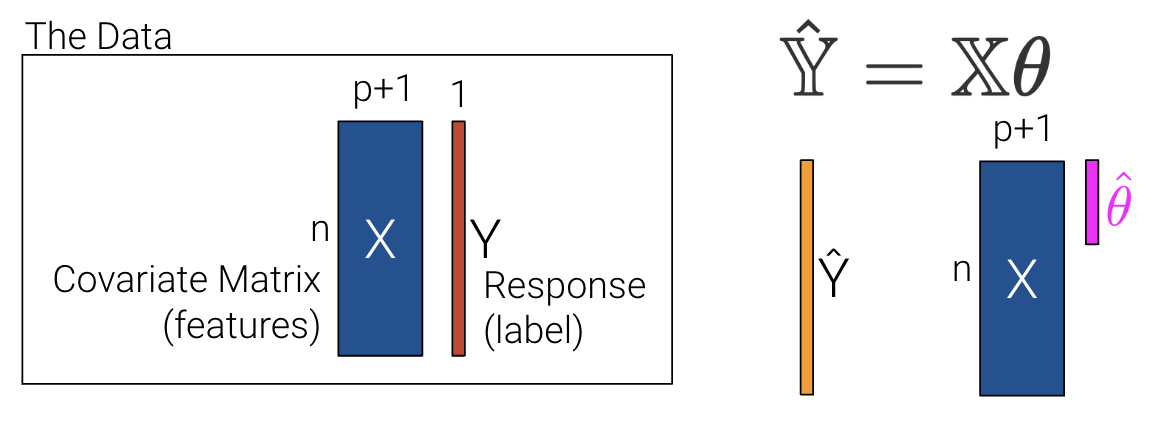

- $p$ as the number of columns in our covariate matrix and add a column of 1s to encode the intercept (if desired)

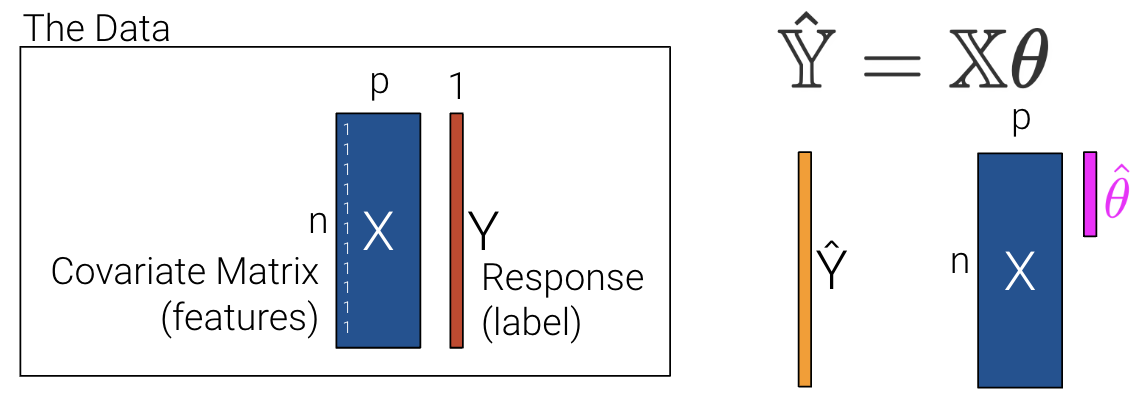

### Choose a loss function

$$R(\theta)
= \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
= \frac{1}{n}\left(\left\|\mathbb{Y}-\hat{\mathbb{Y}}\right\|_2\right)^2$$

### Fit the model

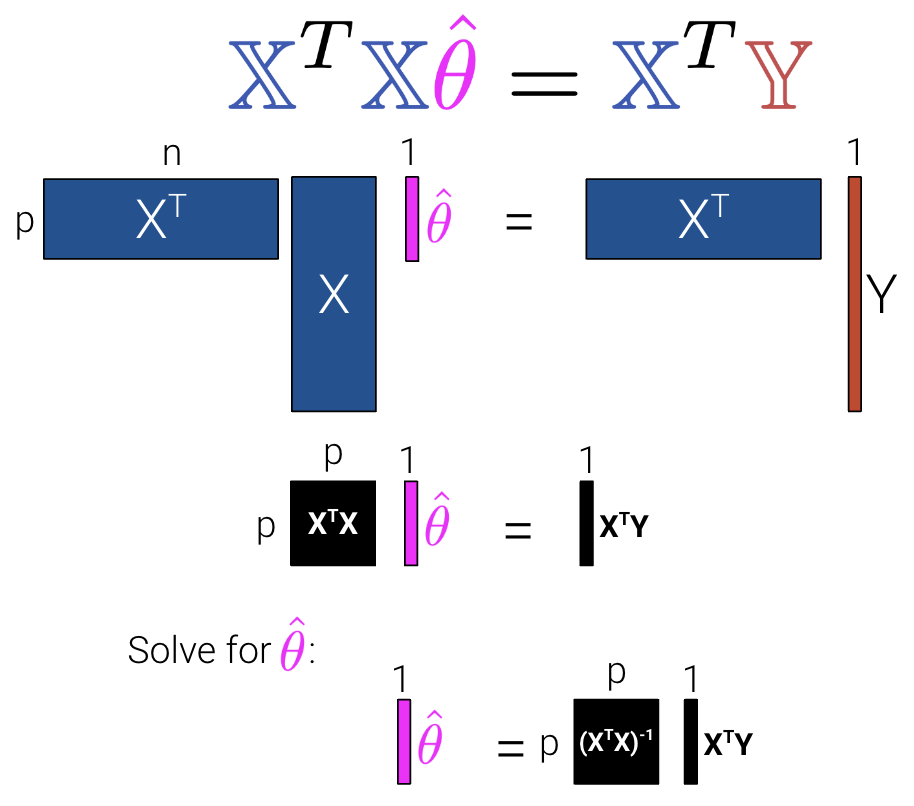

## 2 `sklearn`

- We can do linear regression by hand (But not efficient)

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

penguins = sns.load_dataset("penguins")
penguins = penguins[penguins["species"] == "Adelie"].dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [5]:
# Add a bias column of all ones to `penguins`
penguins["bias"] = np.ones(len(penguins), dtype=int) 

# Define the design matrix, X...
# Note that we use .to_numpy() to convert our DataFrame into a NumPy array so it is in Matrix form
X = penguins[["bias", "flipper_length_mm", "body_mass_g"]].to_numpy()

# ...as well as the target variable, Y
# Again, we use .to_numpy() to convert our DataFrame into a NumPy array so it is in Matrix form
Y = penguins[["bill_depth_mm"]].to_numpy()

In [6]:
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ Y
theta_hat

array([[1.10029953e+01],
       [9.82848689e-03],
       [1.47749591e-03]])

In [7]:
Y_hat = X @ theta_hat
pd.DataFrame(Y_hat).head()

,0
0,18.322561
1,18.445578
2,17.721412
3,17.997254
4,18.263268


### The `sklearn` Workflow

- We don't want to do the calculation manually

- Algotithm should be able to run itself

- `sklearn` is a robust **library of machine learning tools** used extensively in research and industry

**Linear regression**

1. **Import** the LinearRegression **model** from sklearn

In [2]:
from sklearn.linear_model import LinearRegression

2. **Create a model object (Initialization)**

	- It generates a new instance of the model class
	
	- i.e. Making a new "copy" of a standard "template" for a model

In [3]:
my_model = LinearRegression()

3. **Fit the model instance with X & Y** `.fit`

    - It will compute the optimal parameters "**behind the scenes**"
 
    - Then **it stores the parameters within the model instance**

In [14]:
# .fit expects a 2D data design matrix, so we use double brackets to extract a DataFrame
X = penguins[["flipper_length_mm"]]
Y = penguins["bill_depth_mm"]

- We use **double brackets** to extract $X$ column(s)

	- Since `.fit` method expects for $X$ to receive a **2-dimensional** data by default (df)
	
    	- Since $X$ can be generalized as a matrix
  
- We use **single bracket** to extract $Y$ colomn

  - Since output usually is just one vector

In [15]:
my_model.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- The `Parameters` toggle here is the initial hyperparameters

- To extract the fitted parameters, we access the attributes

  - **Caveat** There is a `_` behind 

In [16]:
my_model.intercept_

np.float64(7.297305899612301)

In [17]:
my_model.coef_

array([0.05812622])

4. **Make prediction** with the **$X$** `.predict`

In [21]:
Y_hat_one_feature = my_model.predict(X)
Y_hat_one_feature[:10]

array([17.81815239, 18.10878351, 18.63191952, 18.51566707, 18.3412884 ,
       17.81815239, 18.63191952, 17.87627861, 18.39941463, 18.80629819])

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Summary**

1. Initialize an instance of model `model_instance = Model_Class()`

2. Train the model using `.fit`

3. Use the fitted model to make predictions `.predict`

</div>

- We can also compute MSE

In [22]:
from sklearn.metrics import mean_squared_error
print(f"The MSE of the model is {mean_squared_error(Y, Y_hat_one_feature)}")

The MSE of the model is 1.3338778799806374


### When $X$ is a matrix (2+ features)

In [23]:
# Step 1: initialize LinearRegression model
two_feature_model = LinearRegression()

# Step 2: fit the model
X_two_features = penguins[["flipper_length_mm", "body_mass_g"]]
Y = penguins["bill_depth_mm"]

two_feature_model.fit(X_two_features, Y)

# Step 3: make predictions
Y_hat_two_features = two_feature_model.predict(X_two_features)

print(f"The MSE of the model is {mean_squared_error(Y, Y_hat_two_features)}")

The MSE of the model is 0.9764070438844


- Is it the same as what we compute manually?

In [25]:
pd.DataFrame({"Y_hat from OLS":np.squeeze(Y_hat), "Y_hat from sklearn":Y_hat_two_features}).head()

,Y_hat from OLS,Y_hat from sklearn
0,18.322561,18.322561
1,18.445578,18.445578
2,17.721412,17.721412
3,17.997254,17.997254
4,18.263268,18.263268


- There are minor differences

- Since we compute the exact solution manually but the computers cannot do it easily, they use some algorithms to appoach it

## 3 Gradient Descent

- Sometimes, it is impossible to get the exact solutions

- We use an iterative algorithm to numerically compute the minimum of the loss

### Minimizing an Arbitrary 1D Function

In [26]:
def arbitrary(x):
    return (x**4 - 15*x**3 + 80*x**2 - 180*x + 144)/10

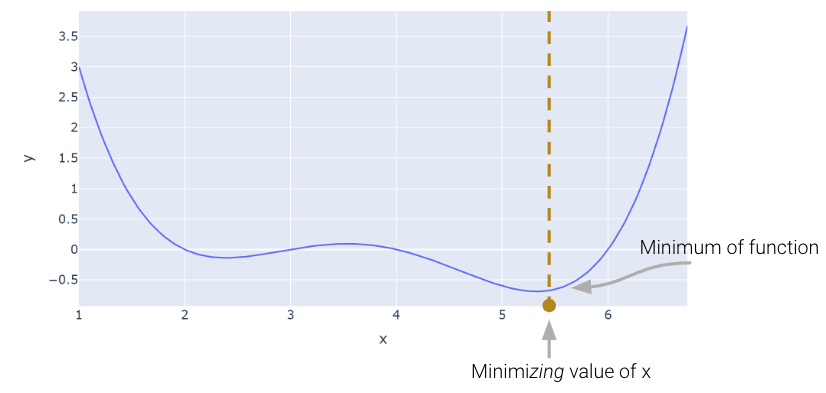

**The Naive Approach: Guess and Check**

- Just try without strategies (Too inefficient and brutal)

- Like we can try one solution at a time

In [27]:
arbitrary(6)

0.0

- Or try a set of possible solutions

In [28]:
def simple_minimize(f, xs):
    # Takes in a function f and a set of values xs. 
    # Calculates the value of the function f at all values x in xs
    # Takes the minimum value of f(x) and returns the corresponding value x 
    y = [f(x) for x in xs]  
    return xs[np.argmin(y)]

guesses = [5.3, 5.31, 5.32, 5.33, 5.34, 5.35]
simple_minimize(arbitrary, guesses)

5.33

- Or try an auto-generated solutions set

In [31]:
# We use plotly here
import plotly.express as px

xs = np.linspace(1, 7, 200)
sparse_xs = np.linspace(1, 7, 5)

ys = arbitrary(xs)
sparse_ys = arbitrary(sparse_xs)

fig = px.line(x = xs, y = arbitrary(xs))
fig.add_scatter(x = sparse_xs, y = arbitrary(sparse_xs), mode = "markers")
fig.update_layout(showlegend= False)
fig.update_layout(autosize=False, width=800, height=600)
fig.show()

**But they have drawbacks**

- If the **minimum is outside our range of guesses**, the answer will be completely wrong

- Even if our range of guesses is correct, if **the guesses are too coarse**, our answer will be **inaccurate**

- Very **computationally inefficient**, considering potentially vast numbers of guesses that are useless

### `Scipy.optimize.minimize`

- There are many optimization methods

In [32]:
from scipy.optimize import minimize

# takes a function f and a starting point x0 and returns a readout 
# with the optimal input value of x which minimizes f
minimize(arbitrary, x0 = 3.5)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.13827491292966557
        x: [ 2.393e+00]
      nit: 3
      jac: [ 6.486e-06]
 hess_inv: [[ 7.385e-01]]
     nfev: 20
     njev: 10

- Much faster, since it uses **gradient descent**

	- Actually `.fit` method also uses gradient descent

### Digging into Gradient Descent

- Starting at $x_0$

- We get derivatives and hence the next direction of movement

In [33]:
import plotly.graph_objects as go

def derivative_arbitrary(x):
    return (4*x**3 - 45*x**2 + 160*x - 180)/10

fig = go.Figure()
roots = np.array([2.3927, 3.5309, 5.3263])

fig.add_trace(go.Scatter(x = xs, y = arbitrary(xs), 
                         mode = "lines", name = "f"))
fig.add_trace(go.Scatter(x = xs, y = derivative_arbitrary(xs), 
                         mode = "lines", name = "df", line = {"dash": "dash"}))
fig.add_trace(go.Scatter(x = np.array(roots), y = 0*roots, 
                         mode = "markers", name = "df = zero", marker_size = 12))
fig.update_layout(font_size = 20, yaxis_range=[-1, 3])
fig.update_layout(autosize=False, width=800, height=600)
fig.show()

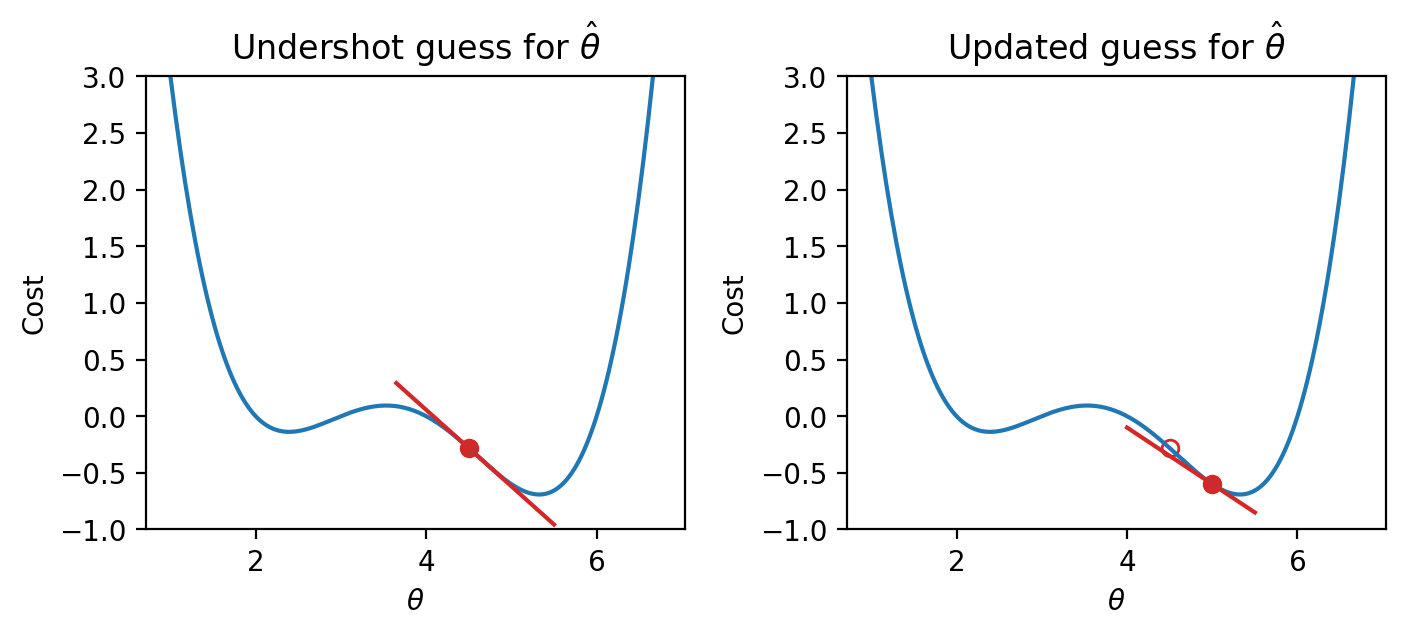

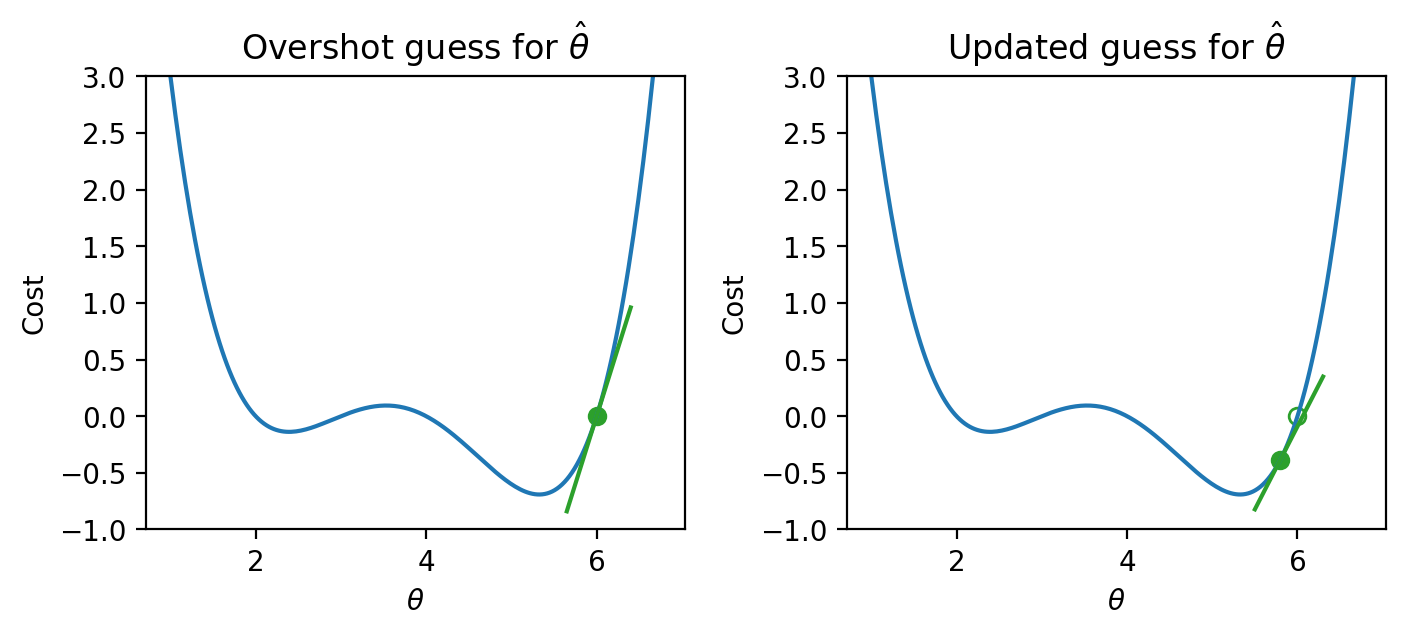

- **Negative slope**: the curve goes down as we **move right**

- **Positive slope**: the curve goes down as we **move left**

- To avoid bouncing around, we use **learning rate $\alpha$**

$$x^{(t+1)} = x^{(t)} - \alpha \frac{d}{dx} f\left(x^{(t)}\right)$$

- A small $\alpha$ means that we will take small steps

- A large $\alpha$ means we will take large steps

- $\alpha$ can also change over time, but here we assume it is constant

<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **When to stop iterating?**

- We set a fixed number (threshold)

- It stops when the difference is smaller than it

</div>

## 4 Convexity

- However, whether we can find the global minimum depends on the initial guess

- Say we start by guessing on the left, it may converge to a local minimum

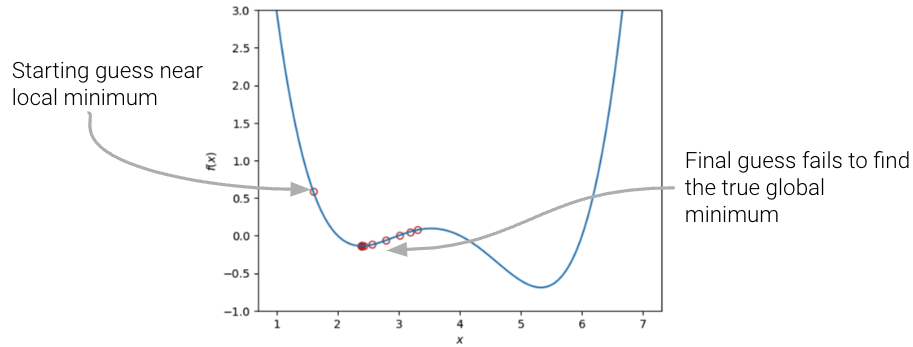

- Gradient descent is guaranteed to find the global minimum if the loss func is **convex**

$$t f(a) + (1-t)f(b) \geq f\left(ta + (1-t)b\right)$$

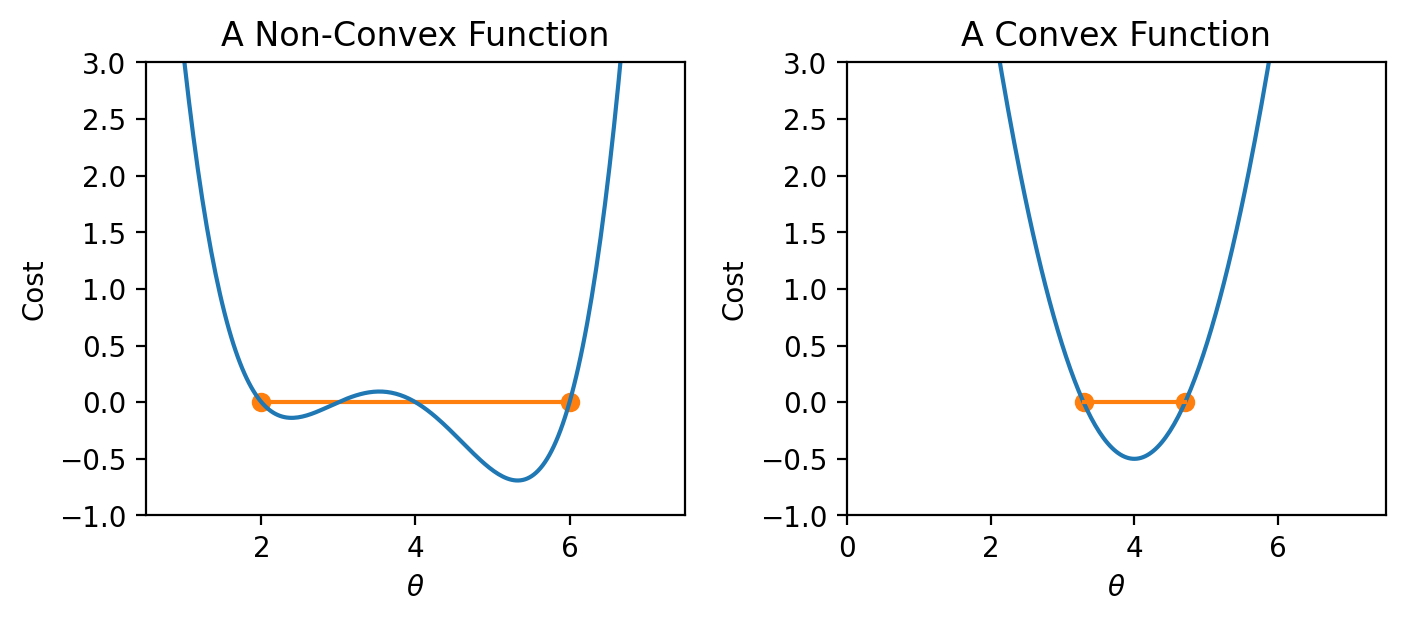

---
[Reference](https://ds100.org/course-notes/gradient-descent/#scipy-optimize-minimize)